## Model Training

In [2]:
import numpy as  np
import pandas as pd

In [3]:
df = pd.read_csv('../data/Analysis.csv')

In [4]:
df.head(2)

,Unnamed: 0.1,Unnamed: 0,customer_id,age,gender,income,product_category,browsing_time,pages_viewed,previous_purchases,discount_used,purchased
0,0,0,109721,56.0,Male,40702.27,Fashion,28.25,19.0,3.0,Yes,1
1,1,1,135306,22.0,Male,14907.71,Grocery,11.25,3.0,4.0,No,1


In [7]:
df['previous_purchases'].unique()

array([ 3.,  4.,  6.,  2.,  5.,  1., nan,  0.,  8.,  7., 60.,  9., 80.,
       10.])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45104 entries, 0 to 45103
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0.1        45104 non-null  int64  
 1   Unnamed: 0          45104 non-null  int64  
 2   customer_id         45104 non-null  int64  
 3   age                 45104 non-null  float64
 4   gender              43477 non-null  object 
 5   income              45104 non-null  float64
 6   product_category    43753 non-null  object 
 7   browsing_time       45104 non-null  float64
 8   pages_viewed        44203 non-null  float64
 9   previous_purchases  43524 non-null  float64
 10  discount_used       43921 non-null  object 
 11  purchased           45104 non-null  int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 4.1+ MB


In [4]:
X  = df.drop(columns=['Unnamed: 0.1','Unnamed: 0','customer_id','purchased'])
y  = df['purchased']

In [ ]:
df.isnull().sum()

Index(['gender', 'product_category', 'discount_used'], dtype='object')

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Features
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns


# Numerical Pipeline
num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)


# Categorical Pipeline
cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)


# Final Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num_pipeline", num_pipeline, num_features),
        ("cat_pipeline", cat_pipeline, cat_features)
    ]
)

In [8]:
X = preprocessor.fit_transform(X)

In [9]:
X.shape

(45104, 18)

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
from sklearn.metrics import   confusion_matrix,accuracy_score,f1_score,recall_score,precision_score

In [17]:
def evaluate_matrix(y_test, y_pred):

    a = accuracy_score(y_test, y_pred)
    c = confusion_matrix(y_test, y_pred)
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy :", a)
    print("Confusion Matrix :")
    print(c)
    print("Precision :", p)
    print("Recall :", r)
    print("F1 Score :", f1)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier,AdaBoostClassifier,GradientBoostingClassifier,VotingClassifier
from xgboost import XGBClassifier

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

models = {

    "LogisticRegression": LogisticRegression(),

    "DecisionTreeClassifier": DecisionTreeClassifier(),

    "Support_Vector_machine": SVC(),

    "KNN": KNeighborsClassifier(),

    "RandomForestClassifier": RandomForestClassifier(),

    "BaggingClassifier": BaggingClassifier(),

    "AdaBoostClassifier": AdaBoostClassifier(),

    "GradientBoostingClassifier": GradientBoostingClassifier(),

    "VotingClassifier": VotingClassifier(
        estimators=[
            ("lr", LogisticRegression()),
            ("dt", DecisionTreeClassifier()),
            ("knn", KNeighborsClassifier())
        ],
        voting="hard"
    )
}

In [22]:
for i in range(len(list(models))):

    model_name = list(models.keys())[i]
    model = list(models.values())[i]

    # Train Model
    model.fit(X_train, y_train)

    # Make Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Model Name
    print(f"\n{'=' * 50}")
    print(f"MODEL: {model_name}")
    print(f"{'=' * 50}")

    # Training Data
    print("\nTRAIN DATA")   
    print("-" * 30)
    evaluate_matrix(y_train, y_train_pred)

    # Testing Data
    print("\nTEST DATA")
    print("-" * 30)
    evaluate_matrix(y_test, y_test_pred)

c:\Users\md salman\anaconda3\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(



MODEL: LogisticRegression

TRAIN DATA
------------------------------
Accuracy : 0.6555995898345481
Confusion Matrix :
[[10188  6707]
 [ 5720 13468]]
Precision : 0.6675588599752168
Recall : 0.7018970189701897
F1 Score : 0.6842974366791149

TEST DATA
------------------------------
Accuracy : 0.6546946014854229
Confusion Matrix :
[[2546 1710]
 [1405 3360]]
Precision : 0.6627218934911243
Recall : 0.7051416579223505
F1 Score : 0.6832740213523132

MODEL: DecisionTreeClassifier

TRAIN DATA
------------------------------
Accuracy : 1.0
Confusion Matrix :
[[16895     0]
 [    0 19188]]
Precision : 1.0
Recall : 1.0
F1 Score : 1.0

TEST DATA
------------------------------
Accuracy : 0.5770978827181023
Confusion Matrix :
[[2326 1930]
 [1885 2880]]
Precision : 0.5987525987525988
Recall : 0.6044071353620147
F1 Score : 0.6015665796344648

MODEL: Support_Vector_machine

TRAIN DATA
------------------------------
Accuracy : 0.6711193636892719
Confusion Matrix :
[[10705  6190]
 [ 5677 13511]]
Precision 

c:\Users\md salman\anaconda3\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(



MODEL: VotingClassifier

TRAIN DATA
------------------------------
Accuracy : 0.8425574370202035
Confusion Matrix :
[[13823  3072]
 [ 2609 16579]]
Precision : 0.8436720777568572
Recall : 0.8640296018344799
F1 Score : 0.8537294986997606

TEST DATA
------------------------------
Accuracy : 0.6381775856335218
Confusion Matrix :
[[2507 1749]
 [1515 3250]]
Precision : 0.6501300260052011
Recall : 0.6820566631689402
F1 Score : 0.665710774272839


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_matrix(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return accuracy, precision, recall, f1

In [24]:
model_list = []
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

for i in range(len(list(models))):

    model_name = list(models.keys())[i]
    model = list(models.values())[i]

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_test_pred = model.predict(X_test)

    # Evaluation
    accuracy, precision, recall, f1 = evaluate_matrix(
        y_test, 
        y_test_pred
    )

    # Store results
    model_list.append(model_name)
    accuracy_list.append(accuracy)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

c:\Users\md salman\anaconda3\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\md salman\anaconda3\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [25]:
import pandas as pd

result = pd.DataFrame({
    "Model": model_list,
    "Accuracy": accuracy_list,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1 Score": f1_list
})

result = result.sort_values(
    by="F1 Score",
    ascending=False
)

result

,Model,Accuracy,Precision,Recall,F1 Score
2,Support_Vector_machine,0.662565,0.672272,0.704722,0.688115
7,GradientBoostingClassifier,0.659794,0.671521,0.696747,0.683902
0,LogisticRegression,0.654695,0.662722,0.705142,0.683274
6,AdaBoostClassifier,0.657023,0.668618,0.695278,0.681687
4,RandomForestClassifier,0.643720,0.658492,0.676180,0.667219
8,VotingClassifier,0.640062,0.652410,0.681847,0.666803
3,KNN,0.603481,0.624008,0.627282,0.625641
5,BaggingClassifier,0.611795,0.647100,0.583001,0.613380
1,DecisionTreeClassifier,0.581532,0.602273,0.611752,0.606976


C:\Users\md salman\AppData\Local\Temp\ipykernel_4248\1500315718.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result, x = "Model", y = "Accuracy", ax=axes[0,0],palette="viridis")
C:\Users\md salman\AppData\Local\Temp\ipykernel_4248\1500315718.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result,x = "Model", y = "Precision", ax=axes[0,1],palette="Blues_d")
C:\Users\md salman\AppData\Local\Temp\ipykernel_4248\1500315718.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result,x = "Model", y = "Recall", ax=axes[1,

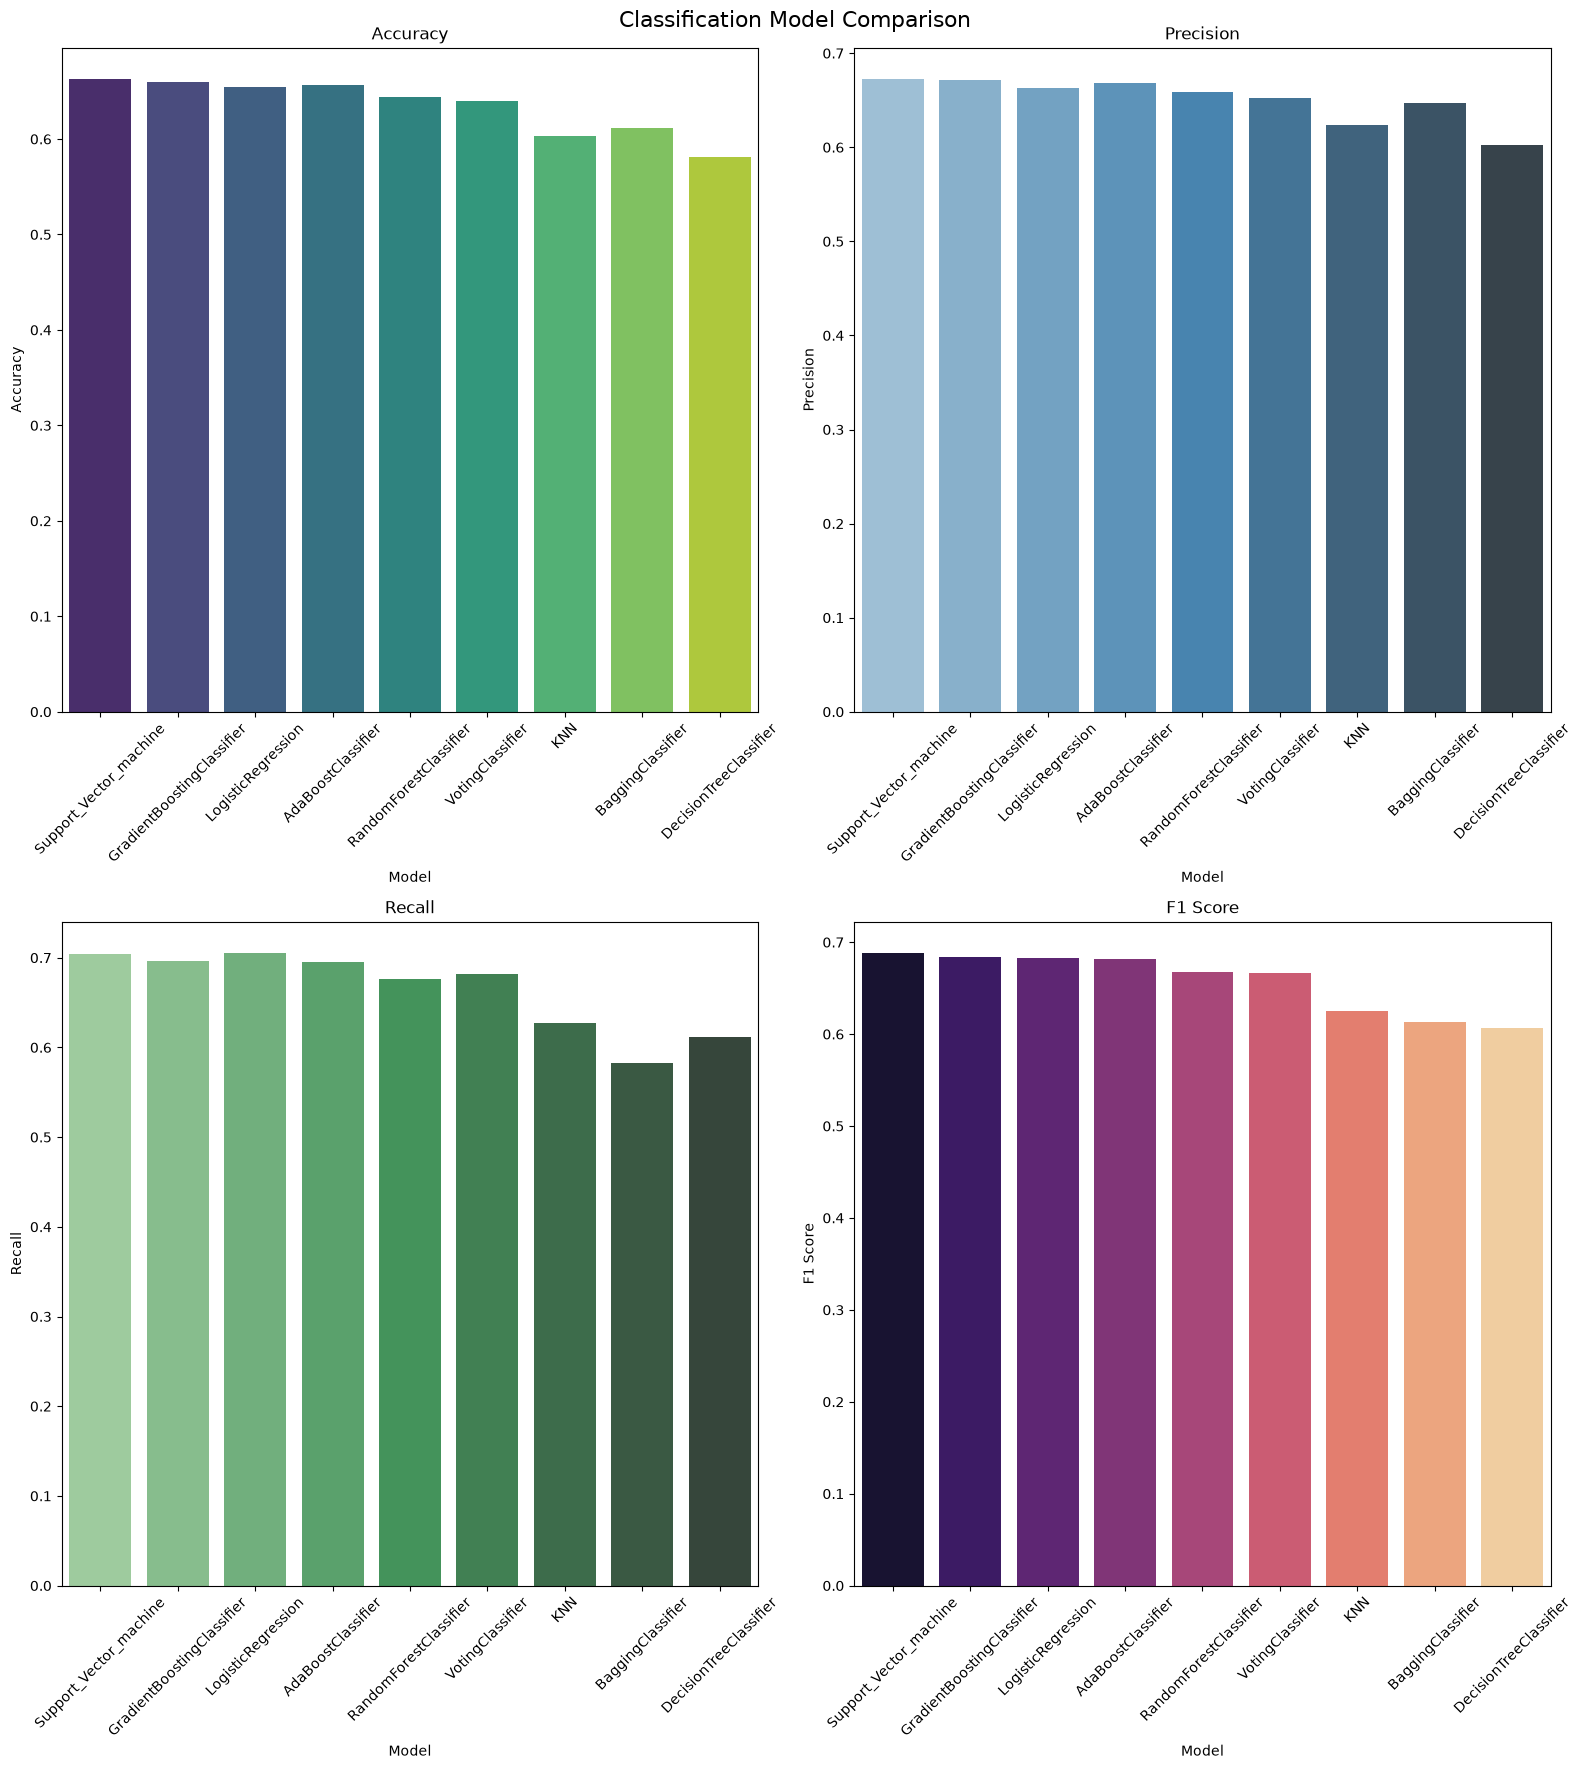

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
fig , axes   = plt.subplots(2,2,figsize=(16,18))

## Accuracy
sns.barplot(data=result, x = "Model", y = "Accuracy", ax=axes[0,0],palette="viridis")
axes[0,0].set_title('Accuracy')
axes[0,0].tick_params(axis='x',rotation=45)

# Precision
sns.barplot(data=result,x = "Model", y = "Precision", ax=axes[0,1],palette="Blues_d")
axes[0,1].set_title("Precision")
axes[0,1].tick_params(axis='x',rotation=45)

# Recall
sns.barplot(data=result,x = "Model", y = "Recall", ax=axes[1,0],palette="Greens_d")
axes[1,0].set_title("Recall")
axes[1,0].tick_params(axis='x',rotation=45)

# F1 Score
sns.barplot(data=result,x = "Model", y = "F1 Score", ax= axes[1,1],palette="magma")
axes[1,1].set_title("F1 Score")
axes[1,1].tick_params(axis='x',rotation=45)

plt.suptitle("Classification Model Comparison", fontsize=16)
plt.tight_layout()
plt.show()